<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color= '#0400ffff'>**Methodology** </font><a class="anchor" id='top'></a>

- [1. Abstract](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
    - [4.1 Define new index](#4_1)
- [5. Data Preprocessing](#5)
    - [5.1 Types Correction](#5_1)
        - [5.1.1 Year and previousOwners columns correction](#5_1_1)
        - [5.1.2 hasDamage Column Correction](#5_1_2)
    - [5.2 Categorical Features correction](#5_2)
        - [5.2.1 Creating the Correction Function](#5_2_1)
        - [5.2.2 Correct the values](#5_2_2)
        - [5.2.3 Check corrections](#5_2_3)
    - [5.3 Invalid Values](#5_3)
        - [5.3.1 Invalid Values Analysis](#5_3_1)
        - [5.3.2 Invalid Values Treatment](#5_3_2)
    - [6 Data Partition](#6)
    - [7 Data Transformation](#7)
        - [7.1 Outliers Treatment](#7_1)
        - [7.2 Feature Engineering without using median, mean or mode](#7_2)
        - [7.3 Feature Engineering considering mean and other calculations](#7_3)
        - [7.4 Missing Values Imputation](#7_4)
        - [7.5 Encoding](#7_5)
        - [7.6 Scaling Features](#7_6)
        - [7.7 Save the Processed Data](#7_7)
- [8 End of The Notebook](#8)


<a class="anchor" id="1">

# **1. Abstract**

[Back to TOP](#TOP)
</a>

This project aims to develop a predictive model capable of estimating car prices based on their characteristics, using the Cars 4 You dataset. The goal is to support the company’s evaluation process by introducing an automated solution that accelerates car assessments and improves overall efficiency.

The current phase of the project focuses on data preprocessing, which involves cleaning, transforming, and preparing the dataset for modeling. This includes handling missing values, encoding categorical features, scaling numerical features, and ensuring data consistency across all attributes. These steps are essential to create a reliable and structured dataset that will serve as the foundation for the subsequent modeling phase.

<a class="anchor" id="2">

# **2. Import Libraries**

[Back to TOP](#TOP)
</a>


The following libraries will help us develop the analyses and model for this project. Pandas and NumPy provide efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Scikit-learn offers a range of Machine Learning tools for model training, splitting the data and evaluating model performance. Then, os, math and ceil are imported to support file management and mathematical operations. SequenceMatcher assists in detecting string similarity for text preprocessing. OneHotEncoder, MinMaxScaler and StandardScaler are used to transform categorical and numerical features into model-ready formats. KNNImputer is applied to handle missing data using nearest-neighbour estimates.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import sys
from math import ceil

from difflib import SequenceMatcher
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load Created Functions
from visualizations import *
from data_preprocessing import *


# Set random seed for reproducibility
np.random.seed(40111) 

<a class="anchor" id="3">

# **3. Metadata**

[Back to TOP](#TOP)
</a>

Understanding the features is essential to interpret the data correctly and conduct the subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An attribute that contains an identifier for each car.

**Brand:** The car's main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**fuelType:** The type of fuel used by the car (Diesel, Petrol, Hybrid, Electric).

**mpg:** The car's consumption of fuel expressed in average miles per gallon.

**engineSize:** Size of the engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.

<a class="anchor" id="4">

# **4. Import Datasets**

[Back to TOP](#TOP)
</a>

Here, we are importing with pd.read_csv() the files to start our project and converting them into Pandas DataFrames. CarID was set to index since it's the unique identifier in all data sets.

In [2]:
train = pd.read_csv('../../data/train.csv')
test = pd.read_csv('../../data/test.csv')

<a class="anchor" id="4">

## **4.1** Define new index

[Back to TOP](#TOP)
</a>

For all partitions we will assign the "carID" column as the index, as it represents the number identifier for each individual car.

In [3]:
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

<a class="anchor" id="5">

# **5. Data Cleaning**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_1">

## **5.1** Types Correction
[Back to TOP](#TOP)
</a>

In the EDA phase we noticed some inconsistencies in the features types. We will decide what to do with these errors and correct them.

Before starting, we will create a copy of the original dataframes to avoid any unwanted changes to the original data.

In [4]:
train = train.copy()
test = test.copy()

We are going to decide how to correct the data and this decision will be based on the percentage of incorrect values.

We will analyse the train dataset and take action in both train and test datasets.

We had previously identified that there are float values in the columns `Year`, `hasDamage` and `previousOwners` that should be integers as they represent discrete variables and a boolean in the case of hasDamage.

<a class="anchor" id="5_1_1">

### **5.1.1** Year and previousOwners columns correction
[Back to TOP](#TOP)
</a>

In [5]:
# percentage of float values in year and previousOwners columns
num_incorrect_year = (train['year'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in year column: {num_incorrect_year:.2f}%')

num_incorrect_previousOwners = (train['previousOwners'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in previousOwners column: {num_incorrect_previousOwners:.2f}%')


Percentage of incorrect values in year column: 2.91%
Percentage of incorrect values in previousOwners column: 3.01%


We decided to round all values of the features because the percentage of incorrect values is close to 3% (minimal). We chose rounding over flooring or ceiling because rounding gives the value that is mathematically closest to the original number, therefore minimizing bias and error.

In [6]:
#Rounds numeric values: values with decimal part >= 0.5 go up, others go down.
for col in ['year', 'previousOwners']:
    train[col] = np.floor(train[col] + 0.5).astype('Int64')
    test[col] = np.floor(test[col] + 0.5).astype('Int64')

<a class="anchor" id="5_1_2">

### **5.1.2** hasDamage Column Correction
[Back to TOP](#TOP)
</a>

In the HasDamage column, we only have 0's and NaN values. We decided to fill the NaN's with 1's to create boolean features by assuming that NaN values mean that there is damage to the car. Our rationale was that the customer prefers to ommit when there is damage to the car to raise its value. 

We agreed that this change was urgent and, because of that, it was done before the splitting.

In [7]:
train['hasDamage']=train['hasDamage'].astype('Int64')
test['hasDamage']=test['hasDamage'].astype('Int64')

train['hasDamage']=train['hasDamage'].fillna(1)
test['hasDamage']=test['hasDamage'].fillna(1)

<a class="anchor" id="5_2">

## **5.2** Categorical Features correction

[Back to TOP](#TOP)

We had identified earlier that the categorical features present a lot of misspellings. We will address that here.

<a class="anchor" id="5_2_1">

### **5.2.1** Creating the Correction Function

[Back to TOP](#TOP)

We start by creating a function that corrects these strange values by using the library difflib.

In [8]:
# Function to calculate similarity between two strings
def similar(a, b):
    """
    Checks similarity between two strings using SequenceMatcher.
    It calculates the percentage of equal characters between both inputs.
    """

    return SequenceMatcher(None, a, b).ratio()


# Function to clean categorical column using difflib
def clean_with_diff(
    df, column,
    threshold_short,
    threshold_long 
):
    """
    Groups similar values and replaces them by the most frequent (mode).
    threshold_short: similarity threshold when both strings have <= 5 chars
    threshold_long: similarity threshold otherwise
    """
    # Get unique values in the column
    values = df[column].dropna().unique()
    groups = []
    used = set()
    
    # Group similar values
    for v in values:
        if v in used:
            continue
        
        # Start a new group
        group = [v]
        used.add(v)
        
        # Compare with other values
        for other in values:
            if other in used:
                continue

            # Choose the thresholds based on length
            if len(v) <= 5 and len(other) <= 5:
                threshold = threshold_short
            else:
                threshold = threshold_long

            # Check similarity. If similar, add to group.
            if similar(v.lower(), other.lower()) >= threshold:
                group.append(other)
                used.add(other)

        # Append the group to the list of groups
        groups.append(group)
    
    # Create mapping for each group and replace values with mode
    mapping = {}
    for group in groups:
        moda = df[df[column].isin(group)][column].mode()[0]
        for item in group:
            mapping[item] = moda
    
    df[column] = df[column].map(mapping).fillna(df[column])
    
    return df


<a class="anchor" id="5_2_2">

### **5.2.2** Correct the values

[Back to TOP](#TOP)

Now we are able to correct the values by calling the function. We have tested the corrections with different thresholds for all variables and landed on these to get the best results. 

In [9]:
# Correct 'Brand' column
clean_with_diff(train, 'Brand', threshold_short=0.6, threshold_long=0.6)
clean_with_diff(test, 'Brand', threshold_short=0.5, threshold_long=0.6)

# Correct 'transmission' column
clean_with_diff(train, 'transmission', threshold_short=0.7, threshold_long=0.7)
clean_with_diff(test, 'transmission', threshold_short=0.7, threshold_long=0.7)

# Correct 'model' column
clean_with_diff(train, 'model', threshold_short=0.70, threshold_long=0.90)
clean_with_diff(test, 'model', threshold_short=0.70, threshold_long=0.90)

# Correct 'fuelType' column
clean_with_diff(train, 'fuelType', threshold_short=0.8, threshold_long=0.8)
clean_with_diff(test, 'fuelType', threshold_short=0.8, threshold_long=0.8)

# The output shows us a part of the dataframe after the values corrections

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I10,2023,Automatic,30700.000000,Petrol,205.0,41.5,1.6,61.0,3,0
106581,VW,Tiguan,2017,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2,0
80886,BMW,2 Series,2016,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2,0
100174,Opel,Grandland X,2019,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1,0
81376,BMW,1 Series,2019,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1,0
81363,BMW,X2,2020,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3,0
76833,Audi,Q5,2019,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4,0


<a class="anchor" id="5_2_3">

### **5.2.3** Check corrections

[Back to TOP](#TOP)

In [10]:
corrected_columns = ['Brand', 'transmission', 'model', 'fuelType']

for column in corrected_columns:
    unique_values_train = train[column].unique()
    unique_values_test = test[column].unique()
    print(f"Unique values on the column '{column}' (train): {unique_values_train}")
    print('')
    print(f"Unique values on the column '{column}' (test): {unique_values_test}")
    print('')
    print('-----------------------------------')
    print('')

Unique values on the column 'Brand' (train): ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'Hyundai' nan]

Unique values on the column 'Brand' (test): ['Hyundai' 'VW' 'BMW' 'Opel' 'Ford' 'Mercedes' 'Skoda' 'Toyota' 'Audi' nan]

-----------------------------------

Unique values on the column 'transmission' (train): ['Semi-Auto' 'Manual' 'Automatic' nan 'unknown' 'Other']

Unique values on the column 'transmission' (test): ['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan 'Other']

-----------------------------------

Unique values on the column 'model' (train): [' Golf' ' Yaris' ' Q2' ' Fiesta' ' 2 Series' ' 3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Class' ' Q3' ' Fabia' ' Ka+'
 ' GLC Class' ' I10' ' C Class' ' Polo' ' E Class' ' Q5' ' Up' ' C-HR'
 ' Mokka X' ' Corsa' ' Astra' ' TT' ' 5 Series' ' Aygo' ' 4 Series' ' SLK'
 ' Viva' ' T-Roc' ' EcoSport' ' Tucson' nan ' X-CLASS' ' X2' ' Rapid'
 ' A1' ' Auris' ' Sharan' ' Adam' ' X3' ' A8' ' B-MAX' ' A4' ' 

**Important Note:** For most of the columns that were corrected, the function seems to have worked properly.
However, in the case of the 'model' column, the results were not as good as in the other columns. This is because the original data contained a high number of unique and incorrect values, some of which were very similar to each other, making it impossible to achieve a perfect correction.

Nevertheless, the vast majority of the data is now properly cleaned and corrected.

Also based on the previous unique values analysis, we decided to check the percentage of the 'Other' category in the 'transmission' column. If the proportion is not significant, we believe it would be reasonable to replace it with an 'Unknown' category, as this simplification could make the next steps of our analysis easier and more consistent.

In [11]:
(train[train['transmission'] == 'Other'].shape[0] / train.shape[0] * 100).__round__(4)

0.0066

The percentage is very small so we are going to replace the category as mentioned before.

In [12]:
#Replace 'Other' to 'Unkown'
train['transmission'] = train['transmission'].replace('Other', 'unknown')
test['transmission'] = test['transmission'].replace('Other', 'unknown')
print(train['transmission'].unique())
print(test['transmission'].unique())

['Semi-Auto' 'Manual' 'Automatic' nan 'unknown']
['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan]


<a class="anchor" id="5_3">

## **5.3** Invalid Values

[Back to TOP](#TOP)

<a class="anchor" id="5_3_1">

### **5.3.1** Invalid Values Analysis

[Back to TOP](#TOP)

In [13]:
# Create a list with the names of metric and categorical columns
metric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType', 'hasDamage']

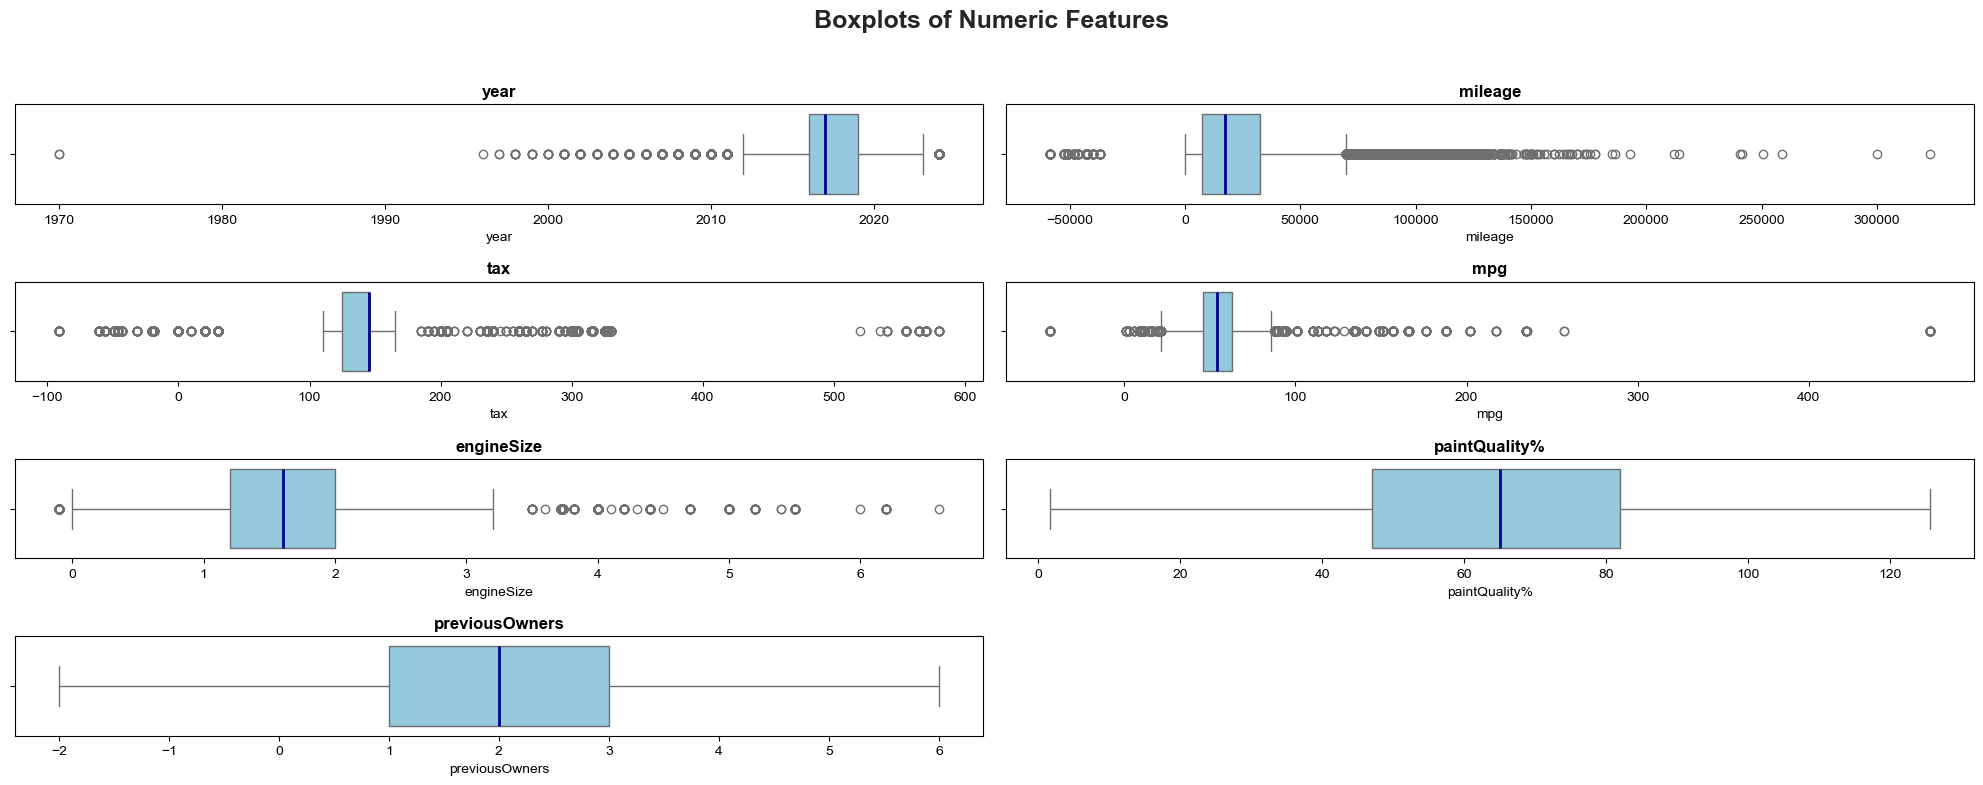

In [14]:
create_boxplots(train, metric_cols)

From the boxplots we found a lot of invalid values. Some features contain negative values (mileage, tax, mpg, engineSize, previousOwners), which are implausible and indicate data-entry errors and the paintQuality% column has values over 100%, which are invalid for a percentage.

Regarding the negative tax values, we thought they could represent to incentives on electric vehicles, so we will check if this checks out.

In [15]:
negtax_electric = train[(train['tax'] < 0) & (train['fuelType'] == 'Electric')]
print(f"Number of rows with negative 'tax' and 'Electric' fuel type: {len(negtax_electric)}")
negtax_electric[['tax', 'fuelType']].head(10)

Number of rows with negative 'tax' and 'Electric' fuel type: 0


,tax,fuelType
carID,,


From this analysis, we see that there are no electric vehicles with negative tax, so we eliminate that possibility.

<a class="anchor" id="5_3_2">

### **5.3.2** Invalid Values Treatment

[Back to TOP](#TOP)

From the conclusions done before and the analysis done in the Exploratory Data Analysis we know that the values with no sense (errors) are a small part of our data and that if we drop them we don't lose veracity.

After considering different approaches, we decided to replace the negative values with NaN since they do not make sense in the context of the features. This approach preserves data integrity and allows for consistent imputation later.
We will also cap the values exceeding 100% at 100%. This approach corrects the impossible values while preserving the rest of the data distribution. 

In [16]:
# Create function to replace negative values with NaN
def replace_negatives_with_nan(df, metric_cols):
    """Replaces negative values in the specified metric columns with NaN."""

    for col in metric_cols:
        num_negatives = (df[col] < 0).sum()
        if num_negatives > 0:
            df.loc[df[col] < 0, col] = np.nan
    return df

# Replace negatives with NaN in both train and test datasets
train = replace_negatives_with_nan(train, metric_cols)
test = replace_negatives_with_nan(test, metric_cols)

In [17]:
# Cap all values at 100%
train['paintQuality%'] = train['paintQuality%'].clip(upper=100)
test['paintQuality%'] = test['paintQuality%'].clip(upper=100)


Now the negative and wrong values are treated. 

**Important:** Before applying any outliers treatment we need to split the data into train and validation sets. This is important to avoid data leakage. After splitting the data we can apply the method using only the training set statistics.

<a class="anchor" id="6">

# **6 Data Partition**

[Back to TOP](#TOP)

Define the independent features as X and the dependent as Y

In [18]:
X = train.drop('price', axis = 1)
y = train['price']

Split the dataset into train and validation

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2, random_state = 0,  shuffle = True)

<a class="anchor" id="7">

# **7 Data Transformation**

[Back to TOP](#TOP)

<a class="anchor" id="7_1">

## **7.1** Outliers Treatment

[Back to TOP](#TOP)

The presence of outliers distorts statistical analysis and affect the performance of machine learning models. To identify them, we decided to use the **Interquartile Range (IQR) method** and apply it to all numerical features. This approach considers values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR as potential outliers. 

The following analysis identifies the number and percentage of outliers per features, helping to evaluate whether data cleaning or transformation might be necessary before modeling.

Here we will create a function to return a summary of the total number of outliers per feature and how much they represent of the total in percentage. This summary is based on the IQR method and we will analyse the train dataset only.

In [20]:
outlier_summary(train, metric_cols)

,Column,Total Outliers,Percentage (%)
0,year,1791,2.36
1,mileage,3248,4.28
2,tax,19928,26.23
3,mpg,1164,1.53
4,engineSize,632,0.83
5,paintQuality%,0,0.00
6,previousOwners,0,0.00


From this, we take that most numeric features do not have a big share of outliers, as they represent less than 5% of all observations. Only the feature `tax` has a very big number of ouliers, with 26.23% of the whole population.

We are now going to analyse these graphically through boxplots.

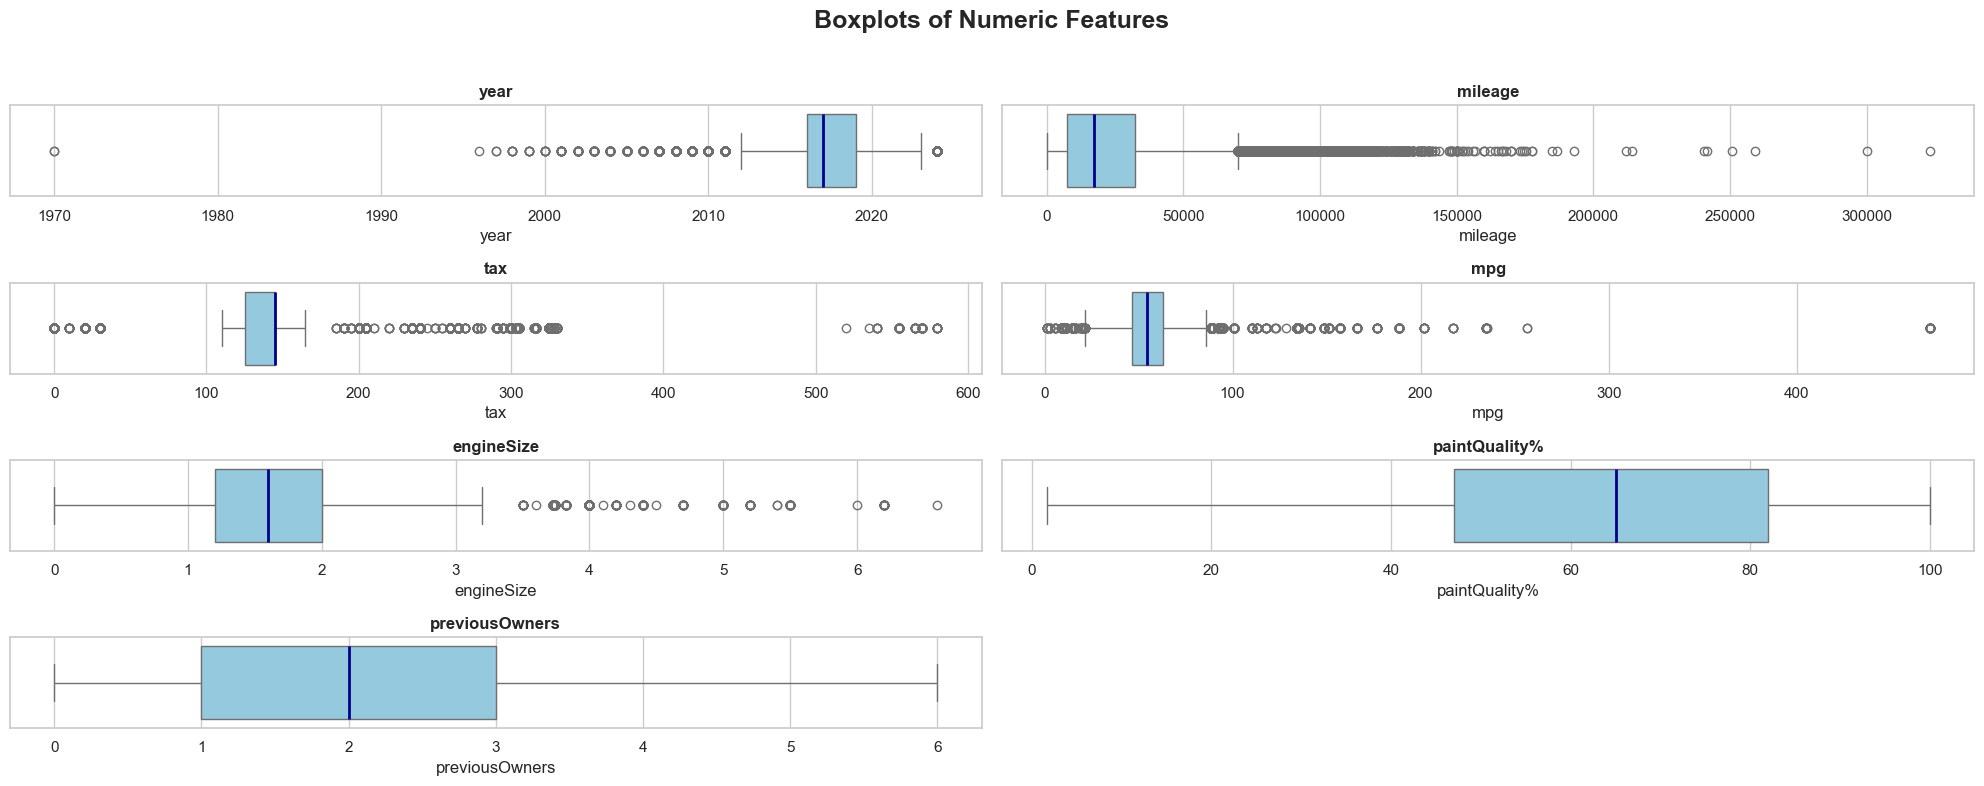

In [21]:
create_boxplots(train, metric_cols)

We started by applying the IQR method and then we realized it eliminated too much data, which then hurt the model's results and decided to create different thresholds specific for each feature. We still kept the code for the IQR method in markdown below. We set each thresholds for the following reasons:

- `year:` Cars older than 1990 were extremely rare and introduced high price variance, while years beyond 2025 are not possible; restricting the range improves data realism and model stability.
- `mileage:` Mileage has a strong right-skew; using a 2.2 IQR multiplier caps extreme values that disproportionately reduce accuracy without removing legitimate high-mileage cases.
- `tax:` Very high tax values occur infrequently and are often errors or special situations; applying a 2.0 IQR multiplier reduces the effect of unrealistic taxation outliers.
- `mpg:` Fuel efficiency extremes are uncommon and distort pricing; a 2.2 IQR multiplier tightens the distribution while preserving real variability across models.
- `engineSize:` Values below 0.9L or above 5.5L correspond to niche or erroneous entries; bounding engine size maintains realistic ranges and limits skew.
- `paintQuality%:` Paint condition cannot logically exceed 100% or go below 0%; enforcing natural bounds ensures data validity.
- `previousOwners:` More than 8 previous owners is highly atypical and signals noisy observations; capping reduces their undue influence on vehicle price.

Apply custom thresholds

In [ ]:
X_train_clean = treat_outliers_custom(X_train, X_train)
X_val_clean = treat_outliers_custom(X_train, X_val)
test_clean = treat_outliers_custom(X_train, test)

In [ ]:
X_train = X_train_clean.copy()
X_val = X_val_clean.copy()
test = test_clean.copy()

Visualize boxplots one more time

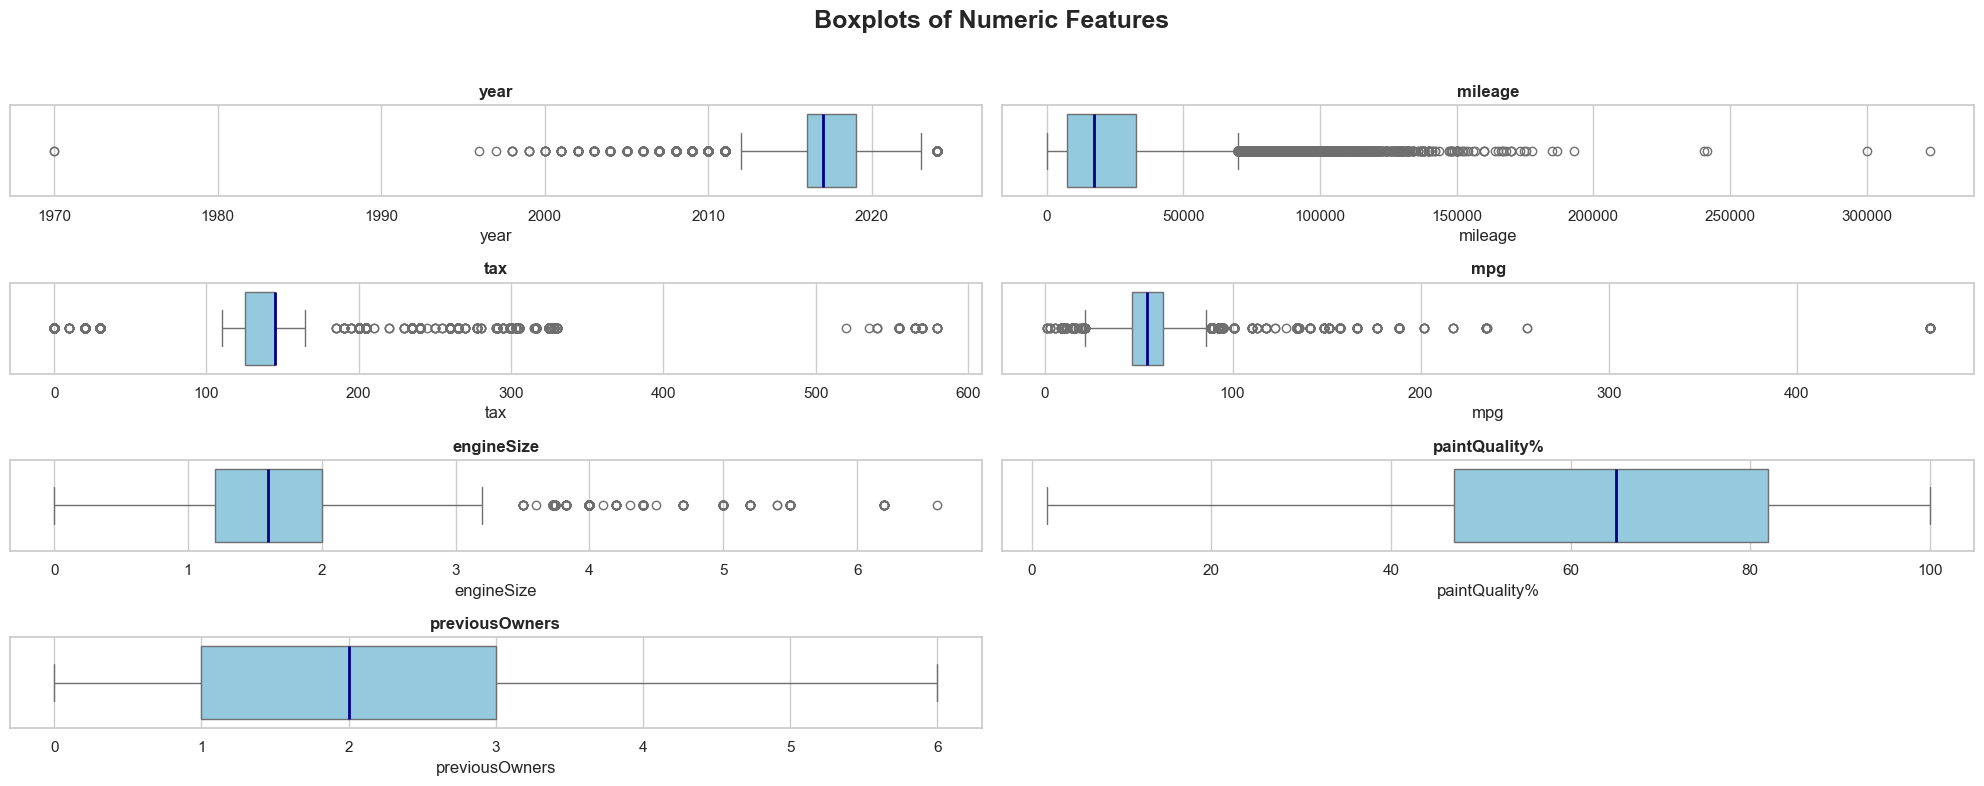

In [24]:
create_boxplots(X_train, metric_cols, figsize=(20,8))

<a class="anchor" id="7_2">

## **7.2** Feature Engineering without using median, mean or mode

[Back to TOP](#TOP)

On this step of the project we created new features that make sense and can help us predicting our target. For now the features that we want to add are:
 - `car_age:` calculate the age of the car considering the current year and the year of its registration. This feature helps us to capture depreciation, this is, older cars tend to be cheaper.

- `is_recent_car:` binary flag, 1 if the car is less than 3 years old, otherwise 0. We decided to create this feature because highlights newer cars, usually have higher resale prices.

- `mileage_category:` transforms the original continuous mileage feature into an ordered categorical feature with five usage levels according to the total mileage.  This way it's easier to capture differences in vehicle wear and market value.

- `is_hybrid_or_eletric:` binary indicator that is 1 if the fuel type is Hybrid or Electric. Eco-friendly cars often hold higher market value.

- `is_automatic:`binary indicator that is 1 if the type of transmission is automatic or semi-automatic. Automatics typically cost more to buy and maintain.

- `fuel_eficciency_score:` Ratio of mpg / engineSize. Captures how efficiently the car converts fuel given engine capacity.

- `tax_to_engine_ratio:` Tax value divided by engine size. Indicates how expensive it is to maintain the car relative to its power.

- `tax_efficency:` mpg / tax. Measures how fuel-efficient the car is relative to its yearly tax burden.

- `is_first_owner:` binary indicator that is 1 if there were no previous owners. First-owner cars tend to have less wear, better care and higher prices. **It was impossible to implement due to missing values**

- `ownership_ratio:` previousOwner / car_age. Captures how frequently ownership changed. Frequent changes might signal reliability issues.

To do this we'll implement some functions that help us defining this new features.

In [25]:
def car_age_features(X, current_year=2020, threshold=3):
    """Calculate car age and flag recent cars."""
    X["car_age"] = current_year - X["year"]
    X["is_recent_car"] = (X["car_age"] <= threshold).astype('Int64')
    return X

def mileage_category(X):
    """Create categorical mileage bins."""
    bins = [0, 10_000, 50_000, 100_000, 150_000, float('inf')]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    X['mileage_category'] = pd.cut(X['mileage'], bins=bins, labels=labels, include_lowest=True)
    return X

def fuel_transmission_features(X):
    """Binary flags for eco-friendly cars and automatic transmission."""
    X["is_hybrid_or_electric"] = X["fuelType"].isin(["Hybrid", "Electric"]).astype('Int64')
    X["is_automatic"] = X["transmission"].isin(["Automatic", "Semi-Auto"]).astype('Int64')
    X["fuel_efficiency_score"] = X["mpg"] / X["engineSize"].replace(0, np.nan)
    return X

def tax_and_efficiency_features(X):
    """Calculate economic indicators based on tax and engine size."""
    X["tax_to_engine_ratio"] = X["tax"] / X["engineSize"].replace(0, np.nan)
    X["tax_efficiency"] = X["mpg"] / X["tax"].replace(0, np.nan)
    return X

def ownership_features(X):
    """Ownership-related features."""
    X["is_first_owner"] = (X["previousOwners"] == 0).round().astype('Int64')
    return X
# --- Function to Apply All Feature Engineering Steps ---

def apply_feature_engineering(X):
    """
    Apply all feature engineering transformations in a pipeline using .pipe().
    This ensures code readability and consistent transformations.
    """
    return (X
            .pipe(car_age_features)
            .pipe(mileage_category)
            .pipe(fuel_transmission_features)
            .pipe(tax_and_efficiency_features)
            .pipe(ownership_features)
           )


In [26]:
X_train_fe = apply_feature_engineering(X_train)
X_val_fe = apply_feature_engineering(X_val)
test_fe = apply_feature_engineering(test)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

<a class="anchor" id="7_3">

## **7.3** Feature Engineering considering mean and other calculations

[Back to TOP](#TOP)

On this step of the project we created new features that make sense and can help us predicting our target. To create these new features we need to do some calculations like median and average. Because of this we are creating them after the train-validation split to avoid data leakage

For now the features that we want to add are:

- `brand_median_mileage:` median mileage per brand. Typical mileage level for each brand that is able to capture brand usage patterns.

- `brand_avg_engineSize`: engineSize mean per brand. Represents typical engine capacity of each brand.

- `model_median_tax:` median tax per model. Captures model-specific taxation tendencies.

- `fueltype_avg_mpg:` mpg mean per fuelType. Average fuel efficiency for each fuel type.

- `brand_avg_age:` car_age mean per brand. Average car age per brand, basically compare newer against older brands.

To do this we'll implement some functions that help us defining this new features.

In [27]:
# Create mapping dictionaries based on TRAIN data only 

# Calculate group statistics using only X_train
brand_median_mileage_map = X_train.groupby('Brand')['mileage'].median().to_dict()
brand_avg_engineSize_map = X_train.groupby('Brand')['engineSize'].mean().to_dict()
model_median_tax_map     = X_train.groupby('model')['tax'].median().to_dict()
fueltype_avg_mpg_map     = X_train.groupby('fuelType')['mpg'].mean().to_dict()
brand_avg_age_map        = X_train.groupby('Brand')['car_age'].mean().to_dict()


# Define a function to apply the mappings to any dataset

def apply_group_based_features(df):
    """Apply precomputed group-based features (from training data) to any dataframe."""

    # Map precomputed values from the training set
    df['brand_median_mileage'] = df['Brand'].map(brand_median_mileage_map)
    df['brand_avg_engineSize'] = df['Brand'].map(brand_avg_engineSize_map)
    df['model_median_tax']     = df['model'].map(model_median_tax_map)
    df['fueltype_avg_mpg']     = df['fuelType'].map(fueltype_avg_mpg_map)
    df['brand_avg_age']        = df['Brand'].map(brand_avg_age_map)

    return df


In [28]:
#Apply mappings to training and validation sets
X_train_fe = apply_group_based_features(X_train)
X_val_fe   = apply_group_based_features(X_val)
test_fe    = apply_group_based_features(test)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

<a class="anchor" id="7_4">

## **7.4** Missing Values Imputation

[Back to TOP](#TOP)

Before starting to fill missing values, we plot a table with the missing value percentages. With this we can easily identify columns with many absent entries and decide whether they are relevant for the model or should be discarded or imputed.

In [29]:
missing_df = missing_values_table(X_train)
missing_df

,Feature,Missing_Percent
0,tax_efficiency,18.281286
1,tax_to_engine_ratio,12.942183
2,fuel_efficiency_score,12.540722
3,tax,10.867419
4,mpg,10.446214
5,previousOwners,2.515713
6,is_first_owner,2.515713
7,mileage,2.364342
8,mileage_category,2.364342
9,engineSize,2.089572


Although some features have missing values, none have a sufficiently high percentage to warrant removal. All columns are considered relevant and can be retained for modeling, with missing values handled through imputation where necessary.

In [30]:
X_train_treated = simple_imputation(X_train, X_train)
X_val_treated = simple_imputation(X_train, X_val)
test_treated = simple_imputation(X_train, test)

In [31]:
X_train = X_train_treated.copy()
X_val = X_val_treated.copy()
test = test_treated.copy()

Now we verify that there are no missing values left in the datasets

In [32]:
# Check that there are no missing values left
if all(df.isnull().sum().sum() == 0 for df in [X_train, X_val, test]):
    print("All datasets are treated and have no missing values.")
else:
    print("There are still missing values in at least one of the datasets.")

All datasets are treated and have no missing values.


<a class="anchor" id="7_5">

## **7.5** Encoding

[Back to TOP](#TOP)

Before training machine learning models, it is necessary to convert categorical features into a numerical format, as most algorithms cannot process non-numeric data directly. This step, known as encoding, ensures that the categorical information can be effectively interpreted by the models without losing its meaning.

In this section, we will apply `One-Hot Encoding` to features with a small number of categories (Brand, Transmission, fuelType) and use a `Ordinal Encoder` for the features that contains many distinct categories (model). This approach allows us to represent all categorical features in a consistent and efficient way, preparing the dataset for further preprocessing and model development.

In [33]:
# Define columns for encoding
one_hot_cols = ['Brand', 'model', 'transmission', 'fuelType', 'mileage_category']

In [34]:
X_train_fit = X_train.copy() # we create a copy to fit the encoders only on training data

X_train_encoded = encoding_features(X_train_fit, X_train, one_hot_cols)
X_val_encoded = encoding_features(X_train_fit, X_val, one_hot_cols)
X_test_encoded = encoding_features(X_train_fit, test, one_hot_cols)
# A warning may appear if some categories in validation/test were not present in training. This happens because the Encoder was fitted only on the training data.
# With this, the program emits a warning and assigns zeros to those unseen categories, but continues to run normally.


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [35]:
# Update dataframes to encoded versions
X_train = X_train_encoded.copy()
X_val = X_val_encoded.copy()
test = X_test_encoded.copy()

Before moving to the next step we need to update the list cat_cols because after enconding new columns were created.

In [36]:
cat_cols = X_train.drop(metric_cols, axis=1).columns.tolist()
cat_cols

['hasDamage',
 'car_age',
 'is_recent_car',
 'is_hybrid_or_electric',
 'is_automatic',
 'fuel_efficiency_score',
 'tax_to_engine_ratio',
 'tax_efficiency',
 'is_first_owner',
 'brand_median_mileage',
 'brand_avg_engineSize',
 'model_median_tax',
 'fueltype_avg_mpg',
 'brand_avg_age',
 'ohe_Brand_BMW',
 'ohe_Brand_Ford',
 'ohe_Brand_Hyundai',
 'ohe_Brand_Mercedes',
 'ohe_Brand_Opel',
 'ohe_Brand_Skoda',
 'ohe_Brand_Toyota',
 'ohe_Brand_VW',
 'ohe_model_ 2 Series',
 'ohe_model_ 3 Serie',
 'ohe_model_ 3 Series',
 'ohe_model_ 4 Series',
 'ohe_model_ 5 Series',
 'ohe_model_ 6 Series',
 'ohe_model_ 7 Series',
 'ohe_model_ 8 Series',
 'ohe_model_ A Class',
 'ohe_model_ A1',
 'ohe_model_ A2',
 'ohe_model_ A3',
 'ohe_model_ A4',
 'ohe_model_ A5',
 'ohe_model_ A6',
 'ohe_model_ A7',
 'ohe_model_ A8',
 'ohe_model_ Accent',
 'ohe_model_ Adam',
 'ohe_model_ Agila',
 'ohe_model_ Amarok',
 'ohe_model_ Ampera',
 'ohe_model_ Antara',
 'ohe_model_ Arteon',
 'ohe_model_ Astra',
 'ohe_model_ Auris',
 'ohe

<a class="anchor" id="7_6">

## **7.6** Scaling Features

[Back to TOP](#TOP)

Numerical features are scaled to ensure all features are in a comparable scale. This preserves relative relationships while preventing features with larger ranges from dominating distance or gradient based algorithms, improving model performance and stability.

In [37]:
# Scale numeric features using our scaling function
X_train_scaled = scaling_features(X_train, X_train, metric_cols, "minmax")
X_val_scaled = scaling_features(X_train, X_val, metric_cols, "minmax")
test_scaled = scaling_features(X_train, test, metric_cols, "minmax")

In [38]:
# Create copies of the treated datasets
X_train = X_train_treated.copy()
X_val = X_val_treated.copy()
test = test_treated.copy()

<a class="anchor" id="7_7">

## **7.7** Save the Processed Data

[Back to TOP](#TOP)

In [39]:
# Create copies of the final datasets to be used in modeling
X_train_final = X_train.copy()
X_val_final = X_val.copy()
test_final = test.copy()

In [40]:
# Go one level up from the notebooks folder to reach the repo root
processed_dir = "../data_preprocessed"
os.makedirs(processed_dir, exist_ok=True)

# Save processed datasets as CSV files
X_train_final.to_csv(f"{processed_dir}/X_train_preprocessed.csv", index=True)
X_val_final.to_csv(f"{processed_dir}/X_val_preprocessed.csv", index=True)
test_final.to_csv(f"{processed_dir}/test_preprocessed.csv", index=True)

y_train.to_csv(f"{processed_dir}/y_train.csv", index=True)
y_val.to_csv(f"{processed_dir}/y_val.csv", index=True)

<a class="anchor" id="8">

# **8 End of The Notebook**

[Back to TOP](#TOP)

From the data preprocessing stage, we ensured that the dataset was properly cleaned and transformed to be ready for modeling. Data inconsistencies were corrected, outliers were treated, missing values were handled, categorical variables were encoded and numerical features were scaled. As a result, the dataset is now more consistent, structured, and suitable for the application of machine learning algorithms. These preprocessing steps provide a solid foundation for the upcoming phases of feature selection and model development.